# Global sensitivity analysis: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [1]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
from SALib.analyze.hdmr import analyze as hdmr_analyze
import sys
import time
import multiprocessing
from tqdm import tqdm
from joblib import Parallel, delayed
sys.path.insert(0, '../odes')

import ampk_MA_double_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True
plt.rcParams['text.usetex'] = False
mpl.rcParams['text.usetex'] = False
# plt.rcParams['mathtext.fontset']='dejavusans'

## Nominal values for the parameters and unknown initial conditions
Notes:
- Will only vary $K_{\rm d, AMP}$, $K_{\rm d, ADP}$, $K_{\rm d, ATP}$, and estimate forward and reverse rates by fixing the forward rate to 1 and setting the reverse rate accordingly. 
$$
    K_{\rm d} = k_r / k_f
$$
- For all enzyme binding parameters we fix the total enzyme concentration, vary Vmax and Km, fix forwarding binding rate and calculate all other parameters accordingly.
To do so, we apply the expressions for the Michaelis-Menten parameters
$$
    K_m = \frac{k_r + k_{cat}}{k_f},
$$
and 
$$
    V_{max} = k_{cat}E_t.
$$
- Assume CamKK2 has a molecular weight of 60-90 kDA (https://www.thermofisher.com/order/catalog/product/PV4206). Thus Vmax varies from 0.286 /s to 0.429 /s. We can take the mean of this as 0.357 1/s as the nominal value
- Assume that the total ExRaiAMPKAR concentration has a nominal value on the same order of magnitude as the initial AMPK concentration. This is $1\times 10^{-1}$ mM.

In [2]:
# define the bounds for the parameters
# we use plus or minus on order of magnitude of any known values and then make reasonable assumptions for unknowns
# Note we fix all off rates to 1.0 and dont bother sampling these or computing sensitivities
############################################
# First for Mass action parameters
nominal_vals_MA = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   90.467, # kOnCaMKK = (koff+kphos/Km)
   0.357, # kPhosCaMKK
   0.742, # kOnLKB1
   3.92e-2, # kPhosLKB1
   16.56, # kOnPP
   1.1e-1, # kDephosPP
   1569.59, # kOnAMPK
   6.33, # kPhosAMPK
   16.56, # kOnPP1
   1.1e-1, # kDephosPP1
   1e-3, # AMPKAR
]

bounds_MA_90 = [[0.1*param, 1.9*param] for param in nominal_vals_MA]

param_names_MA = ['KdAMP', 'KdADP', 'KdATP', 'kOnCaMKK', 'kPhosCaMKK', 
               'kOnLKB1','kPhosLKB1','kOnPP','kDephosPP', 
               'kOnAMPK','kPhosAMPK', 'kOnPP1','kDephosPP1', 'AMPKAR']
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']

############################################
# We also want to sample Michaelis-Menten parameters to generate correlated samples
# of the mass action parameters
nominal_vals_MM = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   0.357, # kPhosCaMKK
   1.5e-2,  # KmCaMKK
   3.92e-2, # kPhosLKB1
   1.4,  # KmLKB1
   1.1e-1, # kDephosPP
   6.7e-2, # KmPP
   6.33, # kPhosAMPK
   4.67e-3, # KmAMPK
   1.1e-1, # kDephosPP1
   6.7e-2, # KmPP1
   1e-3, # AMPKAR
]

bounds_MM_90 = [[0.1*param, 1.9*param] for param in nominal_vals_MM]

param_names_MM = ['KdAMP', 'KdADP', 'KdATP', 'kPhosCaMKK', 'KmCamKK', 'kPhosLKB1', 'KmLKB1', 'kDephosPP', 'KmPP', 'kPhosAMPK', 'KmAMPK', 
               'kDephosPP1', 'KmPP1', 'AMPKAR']

# dictionary of the problem for SALib
problem_MA_90 = {'num_vars':14, 'names':param_names_MA, 'bounds': bounds_MA_90,}
problem_MM_90 = {'num_vars':14, 'names':param_names_MM, 'bounds': bounds_MM_90,}


seed = np.random.seed(seed=2048)

We will start by defining a function that takes a matrix of paramss and evaluates the model accordingly

In [3]:
def set_init_conds(problem_ode, state_names):
    """ Function to set non-zero initial conditions for the models."""
    y0 = np.zeros((), dtype=problem_ode.state_dtype)
    to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'PP1', 'AMPKAR']
    not_set = list(set(state_names) - set(to_set))
    
    #update nonzero ICs
    y0['AMP'] = 2e-5   # 'AMP' mM
    y0['ADP'] = 1.3e-1 # 'ADP mM
    y0['ATP'] = 8.2   # 'ATP mM
    # # free AMPK
    y0['AMPK'] = 0.6   # 'AMPK mM
    y0['CaMKK'] = 1.0   # 'CaMKK_AMPK mM
    y0['LKB1'] = 1.0   # 'CaMKK_AMPK mM
    y0['PP'] = 1.0   # 'CaMKK_AMPK mM
    y0['AMPKAR'] = 0.1   # 'AMPKAR mM
    y0['PP1'] = 1.0   # 'CaMKK_AMPK mM

    # update zero ICs
    for state in not_set:
        y0[state] = 0.0
        
    return y0

def single_model_eval(params, problem_ode, solver, y0, tvals, state_names):
    """ Function to evaluate the model at a single set of parameters. 
    Runs system to steady state, then applies 2-DG stimulus and runs to steady state again.

    Evaluates the chosen QoIs at the steady state after the perturbation.

    Inputs:
        params: list of parameters to evaluate the model at
        problem_ode: ODE model for sunode
        solver: solver for sunode
        y0: initial conditions for the model
        tvals: time values to evaluate the model
        state_names: list of state names for the model
    """

    sol_init, times_init = sim_to_steady_state(params, 1300.0, problem_ode, 
                        solver, y0, tvals, state_names, make_p_dict_fun_MA, thresh=1e-6,)
    y0_new = np.zeros((), dtype=problem_ode.state_dtype)
    for state in state_names:
        y0_new[state] = sol_init[state][-1]

    sol_stim, times_stim = sim_to_steady_state(params, 4.5, problem_ode, 
                        solver, y0_new, tvals, state_names, make_p_dict_fun_MA, thresh=1e-6,)

    # now compute the output QoIs
    # pAMPKAR/AMPKAR steady-state before perturb
    pAMPKAR_AMPKAR_ss = sol_init.view(problem_ode.state_dtype)['pAMPKAR'][-1] / sol_init.view(problem_ode.state_dtype)['AMPKAR'][-1]

    # change after glycolysis perturbation
    pAMPKAR_AMPKAR_final_ss = sol_stim.view(problem_ode.state_dtype)['pAMPKAR'][-1] / sol_stim.view(problem_ode.state_dtype)['AMPKAR'][-1]
    pAMPKAR_AMPKAR_delta = (pAMPKAR_AMPKAR_final_ss - pAMPKAR_AMPKAR_ss)/pAMPKAR_AMPKAR_ss

    return np.array([pAMPKAR_AMPKAR_ss, pAMPKAR_AMPKAR_delta]), sol_init, sol_stim, times_init, times_stim

def sim_to_steady_state(params, glyco_flux, problem_ode, 
                        solver, y0, tvals, state_names,
                        make_p_dict_fun,
                        thresh=1e-6, t_int_add=100, t_cnt_add=200, max_add_iter=1e6):
    """ Function to simulate the model to steady state.
    
    Checks for steady state after simulation for time defined by tvals. Steady state 
    is evaluated by the check_steady_state function which checks in the mean gradient of the last
    4 time points normalized to the mean of the last for time points is smaller than the threshold. 
    If steady state is not reached, will run 100s simulations until steady state is reached.

    Inputs:
    ------- 
            params: list of parameters
            glyco_flux: glycolysis flux
            problem_ode: ODE problem for sunode
            solver: solver for sunode
            y0: initial conditions
            tvals: time points to simulate
            state_names: list of state names
            make_p_dict_fun: function to make parameter dictionary
            thresh: threshold for steady state checking
            t_int_add (optional): time interval to add to tvals if steady state
                                    is not reached (default: 100s)
            t_cnt_add (optional): number of time points to add to tvals if steady state
                                    is not reached (default: 200)
            max_add_iter (optional): maximum number of iterations to add to tvals if not steady state
                                    (default: 50)
    
    Returns:
    -------
            solution: solution to the ODE evaluated at tvals plus any additional time points 
                        if steady state is not reached
            times: time points for solution (tvals + any additional time points)
    """
    ######################
    # IC and parameters
    # update relevant initial conditions 
    y0['AMPKAR'] = params[13]

    # set the parameters
    solver.set_params_dict(make_p_dict_fun(params, glyco_flux))

    # list to store all sols
    sol_list = []

    ######################
    # simulation
    # initial simulation for tvals
    yout = solver.make_output_buffers(tvals)
    solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)
    sol_list.append(yout)

    # check for steady state
    pAMPKAR_AMPKAR = yout.view(problem_ode.state_dtype)['pAMPKAR'] / yout.view(problem_ode.state_dtype)['AMPKAR']
    ss_check = check_steady_state(pAMPKAR_AMPKAR, thresh)

    # if not steady state, run in 100 second intervals until steady state
    n_additional_sims = 0 # count number of additional simulations
    while not ss_check and n_additional_sims <= max_add_iter:
        n_additional_sims += 1
        # update initial conditions with previous simulation
        y0_new = np.zeros((), dtype=problem_ode.state_dtype)
        for state in state_names:
            y0_new[state] = yout.view(problem_ode.state_dtype)[state][-1]

        # run again
        tvals_inter = np.linspace(0, t_int_add, t_cnt_add)
        yout = solver.make_output_buffers(tvals_inter)
        solver.solve(t0=0, tvals=tvals_inter, y0=y0_new, y_out=yout)
        sol_list.append(yout)

        # check for steady state
        pAMPKAR_AMPKAR = yout.view(problem_ode.state_dtype)['pAMPKAR'] / yout.view(problem_ode.state_dtype)['AMPKAR']
        ss_check = check_steady_state(pAMPKAR_AMPKAR, thresh)
    
    if n_additional_sims == max_add_iter:
        print('WARNING: max number of additional simulations reached. Steady state not reached.')

    # compile sol_list into one solution trajecotry
    # first need the overall shape
    shape = (sum([sol.shape[0] for sol in sol_list]),1)
    solution = np.zeros(shape, dtype=problem_ode.state_dtype)
    for state in state_names: # iterate over sols
        temp = [sol.view(problem_ode.state_dtype)[state] for sol in sol_list]
        solution[state] = np.vstack(temp)
    times = np.hstack([tvals, 
                       np.linspace(tvals[-1], tvals[-1] + n_additional_sims*t_int_add, 
                                   n_additional_sims*t_cnt_add)])
    return solution, times

def check_steady_state(traj, thresh, n=4):
    """ Function to check if a trajectory is at steady state.
    
    Checks if the mean gradient of the last n time points normalized to the
        mean of the last n times is less than the threshold.

    Inputs:
    -------
            traj: trajectory to check
            thresh: threshold for steady state checking
            n (optional): number of time points to check (default: 4)
    """
    n *= -1
    grad = np.abs(np.gradient(traj, axis=0))
    return np.mean(grad[n:])/np.mean(traj[n:]) <= thresh


def make_p_dict_fun_MA(params, glyco_flux):     
    """ Returns the parameters dictionary for the MA model.
    
    Inputs: params - vector of variable parameters
            glyco_flux - glycolysis flux
    Outputs: p_dict - dictionary of parameters
    """
    return {
        'kOnAMP': 1.0, # 1/(mM s) 
        'kOffAMP': params[0], 
        'kOnADP': 1.0 ,
        'kOffADP': params[1],
        'kOnATP': 1.0, 
        'kOffATP': params[2],
        'kOnCaMKK': params[3],
        'kOffCaMKK': 1.0, 
        'kPhosCaMKK': params[4], 
        'kOnLKB1': params[5], 
        'kOffLKB1': 1.0,
        'kPhosLKB1': params[6], 
        'kOnPP': params[7], 
        'kOffPP': 1.0,
        'kDephosPP': params[8],
        'kOnAMPK': params[9],
        'kOffAMPK': 1.0,
        'kPhosAMPK': params[10],
        'kOnPP1': params[11],
        'kOffPP1': 1.0,
        'kDephosPP1': params[12],
        'kGly': glyco_flux,
        'kHydro':1.4e-3,
        'kForAK':40.44,
        'kRevAK':1.1e-3,
        'VmaxOxPhos':0.5,
        'Kadp': 5.8e-2,
        'n': 2.568,
    }


In [4]:
# This is just overhead for the solver
# SET UP problem and SOLVER
# load the necessary dictionaries
params = model1.ampk_MA_double_mech_get_params()
states = model1.ampk_MA_double_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem_ode = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.ampk_MA_double_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# solver
solver = sunode.solver.Solver(problem_ode, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000) # increase max steps

y0 = set_init_conds(problem_ode, state_names)

 # evaluate the solution at these times
tvals = np.linspace(0, 1000, 2000)


In [5]:
# generate samples using the Saltelli and Morris sampling methods
# START with a small number of samples
nsamps = 8
param_vals_sobol_MA = sobol_samp.sample(problem_MA_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MA = morris_samp.sample(problem_MA_90, nsamps, seed=seed)
param_vals_sobol_MM = sobol_samp.sample(problem_MM_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MM = morris_samp.sample(problem_MM_90, nsamps, seed=seed)

# copy MA to np arrays
param_vals_sobol_MA_corr = np.array(param_vals_sobol_MA)
param_vals_morris_MA_corr = np.array(param_vals_morris_MA)
param_vals_sobol_MM_np = np.array(param_vals_sobol_MM)
param_vals_morris_MM_np = np.array(param_vals_morris_MM)

# now compute all kons using samples of Km and from the MM model and Kcat from MA model
kcat_idxs_MA = [4,6,8,10,12]
kon_idxs_MA = [3,5,7,9,11]
km_idxs_MM = [4,6,8,10,12]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):
    param_vals_sobol_MA_corr[:,kon_i] = (1+param_vals_sobol_MA_corr[:,kcat_i])/param_vals_sobol_MM_np[:,km_i]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):  
    param_vals_morris_MA_corr[:,kon_i] = (1+param_vals_morris_MA_corr[:,kcat_i])/param_vals_morris_MM_np[:,km_i]

In [ ]:
y0 = set_init_conds(problem_ode, state_names)
num_jobs=12
param_vals_sobol_MA_corr= tqdm(param_vals_sobol_MA_corr)
param_vals_morris_MA_corr= tqdm(param_vals_morris_MA_corr)
sols_sobol_corr = Parallel(n_jobs=num_jobs)(delayed(single_model_eval)(param, problem_ode, 
                      solver, y0, tvals, state_names) for param in param_vals_sobol_MA_corr)

sols_morris_corr = Parallel(n_jobs=num_jobs)(delayed(single_model_eval)(param, problem_ode, 
                      solver, y0, tvals, state_names) for param in param_vals_morris_MA_corr)

100%|████████████████████████████████████████████████████████████████████████████████████| 128/128 [01:08<00:00,  1.87it/s]

 30%|█████████████████████████▌                                                           | 36/120 [01:37<02:36,  1.87s/it]

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5,2.5))
for a in sols_sobol_corr:
    ax.plot(a[3], a[1].view(problem_ode.state_dtype)['pAMPKAR']/a[1].view(problem_ode.state_dtype)['AMPKAR'],
            'k', alpha=0.5)
    ax.plot(1+a[3][-1]+a[4], a[2].view(problem_ode.state_dtype)['pAMPKAR']/a[2].view(problem_ode.state_dtype)['AMPKAR'],
            'b', alpha=0.5)
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
ax.set_title('Steady-state checking (128 Sobol Samples)')
fig.savefig('./MA_double_mech/sobol_corr_ss_check.pdf')

In [ ]:
# plot the solutions
fig, ax = plt.subplot_mosaic(
    [['traj A', 'traj B'],
     ['traj A', 'traj B'],
     ['hist A', 'hist B'],
     ['hist A', 'hist B'],
     ['hist C', 'hist D'],
     ['hist E', 'hist F']],figsize=(14,8))
for sol in sols_sobol_corr:
    ax['traj A'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist A'].hist(np.array([sol[0][1] for sol in sols_sobol_corr]), color='k')
ax['hist C'].hist(np.array([sol[0][0] for sol in sols_sobol_corr]), color='k')
ax['hist E'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sols_sobol_corr]), color='k')

    

for sol in sols_morris_corr:
    ax['traj B'].plot(sol[4], sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR'], color='k', alpha=0.1)
ax['hist B'].hist(np.array([sol[0][1] for sol in sols_morris_corr]), color='k')
ax['hist D'].hist(np.array([sol[0][0] for sol in sols_morris_corr]), color='k')
ax['hist F'].hist(np.array([sol[0][1]*sol[0][0]+sol[0][0] for sol in sols_morris_corr]), color='k')


# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Sobol Sampling')
ax['traj A'].set_yscale('log')

ax['hist A'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist A'].set_ylabel('Count')
ax['hist A'].set_xlim([0.0, 200.0])

ax['hist C'].set_xlabel('pAMPKAR/AMPKAR before stimulus', labelpad=15)
ax['hist C'].set_yscale('log')

ax['hist E'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist E'].set_yscale('log')

ax['traj B'].set_xlabel('time (s)')
ax['traj B'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj B'].set_title('Morris Sampling')
ax['traj B'].set_yscale('log')

ax['hist B'].set_xlabel('normalized $\Delta$ pAMPKAR/AMPKAR')
ax['hist B'].set_ylabel('Count')
ax['hist B'].set_xlim([0.0, 200.0])

ax['hist D'].set_xlabel('pAMPKAR/AMPKAR initial condition', labelpad=15)
ax['hist D'].set_yscale('log')

ax['hist F'].set_xlabel('pAMPKAR/AMPKAR after stimulus', labelpad=15)
ax['hist F'].set_yscale('log')
fig.savefig('./MA_double_mech/bounds_test.pdf')

### Now generate more samples for the actual analysis

In [ ]:
# generate samples using the Saltelli and Morris sampling methods
# START with a small number of samples
nsamps = 1024
# uncorrelated
param_vals_sobol_MA = sobol_samp.sample(problem_MA_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MA = morris_samp.sample(problem_MA_90, nsamps, seed=seed)
param_vals_sobol_MM = sobol_samp.sample(problem_MM_90, nsamps, calc_second_order=False, seed=seed)
param_vals_morris_MM = morris_samp.sample(problem_MM_90, nsamps, seed=seed)

# correlated
# copy MA to np arrays
param_vals_sobol_MA_corr = np.array(param_vals_sobol_MA)
param_vals_morris_MA_corr = np.array(param_vals_morris_MA)
param_vals_sobol_MM_np = np.array(param_vals_sobol_MM)
param_vals_morris_MM_np = np.array(param_vals_morris_MM)

# now compute all kons using samples of Km and from the MM model and Kcat from MA model
kcat_idxs_MA = [4,6,8,10,12]
kon_idxs_MA = [3,5,7,9,11]
km_idxs_MM = [4,6,8,10,12]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):
    param_vals_sobol_MA_corr[:,kon_i] = (1+param_vals_sobol_MA_corr[:,kcat_i])/param_vals_sobol_MM_np[:,km_i]
for kcat_i, kon_i, km_i in zip(kcat_idxs_MA, kon_idxs_MA, km_idxs_MM):  
    param_vals_morris_MA_corr[:,kon_i] = (1+param_vals_morris_MA_corr[:,kcat_i])/param_vals_morris_MM_np[:,km_i]

### Now run the model with the samples

In [ ]:
# now run the model with the Sobol set of samples
tstart = time.time()
sobol_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol_MA]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol_MA.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_sobol_samples', np.array(sobol_outputs))
# sobol_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_sobol_samples.npy')

Simulating the 163840 Sobol parameter sets took 4290.120934009552 seconds


In [ ]:
# now run the model with the correlated Sobol set of samples
tstart = time.time()
sobol_outputs_corr = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol_MA_corr]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol_MA_corr.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_sobol_samples_corr', np.array(sobol_outputs))

In [ ]:
# And the Morris set of samples
tstart = time.time()
morris_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris_MA]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris_MA.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_morris_samples', np.array(morris_outputs))
# morris_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_morris_samples.npy')

Simulating the 81920 Morris parameter sets took 1044.4503779411316 seconds


In [ ]:
# And the Morris set of samples
tstart = time.time()
morris_outputs_corr = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris_MA_corr]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris_MA_corr.shape[0], tend-tstart))

np.save('./MA_double_mech/20230407_GSA_MA_double_mech_morris_samples', np.array(morris_outputs))
# morris_outputs = np.load('./MA_double_mech/20230320_GSA_MA_double_mech_morris_samples.npy')

### Compute relevant sensitivity indices

In [ ]:
# convert lists to numpy arrays and remove extra dimension
m_outputs_np = np.squeeze(np.array(morris_outputs))
s_outputs_np = np.squeeze(np.array(sobol_outputs))
m_outputs_corr_np = np.squeeze(np.array(morris_outputs_corr))
s_outputs_corr_np = np.squeeze(np.array(sobol_outputs_corr))

# compute Sobol and Morris indices
Si_morris_ss = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,0])
Si_morris_delta = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,1])
Si_sobol_ss = sobol_analyze.analyze(problem_90, s_outputs_np[:,0], calc_second_order=True)
Si_sobol_delta = sobol_analyze.analyze(problem_90, s_outputs_np[:,1], calc_second_order=True)

# compute HDMR indices


In [ ]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_ss['S1'], Si_sobol_ss['S1_conf'], 
                                                                     Si_sobol_ss['ST'], Si_sobol_ss['ST'])], dtype=dtype)
Si_sobol_ss_sorted = np.sort(Si_sobol_ss_sorted, order='S1')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], 
                                                                     Si_sobol_delta['ST'], Si_sobol_delta['ST'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='S1')[::-1]

# sort Morris indices by mu_star
dtype = [('name', 'S10'), ('mu_star', float), ('sigma', float), ('mu', float), ('mu_star_conf', float)]

Si_morris_ss_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_ss['mu_star'], Si_morris_ss['sigma'], 
                                                                     Si_morris_ss['mu'], Si_morris_ss['mu_star_conf'])], dtype=dtype)
Si_morris_ss_sorted = np.sort(Si_morris_ss_sorted, order='mu_star')

Si_morris_delta_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_delta['mu_star'], Si_morris_delta['sigma'], 
                                                                     Si_morris_delta['mu'], Si_morris_delta['mu_star_conf'])], dtype=dtype)
Si_morris_delta_sorted = np.sort(Si_morris_delta_sorted, order='mu_star')

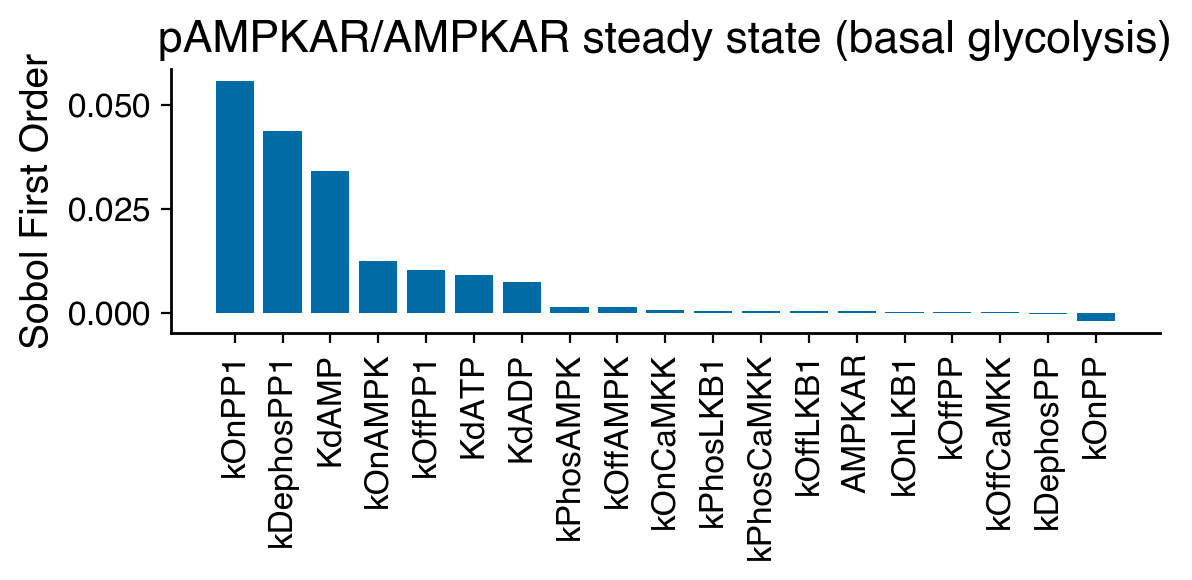

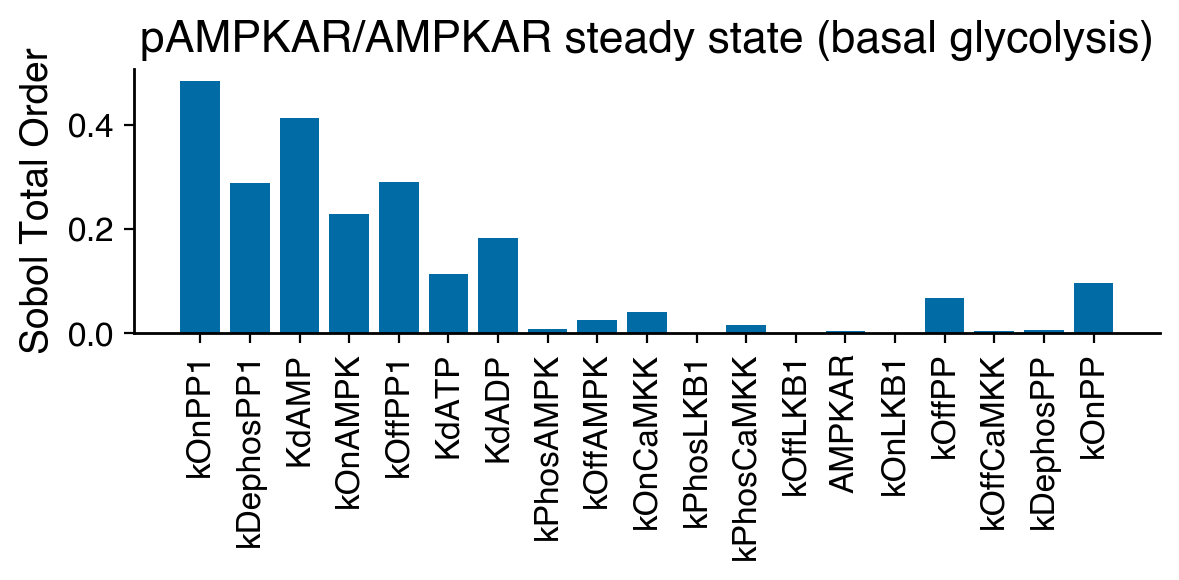

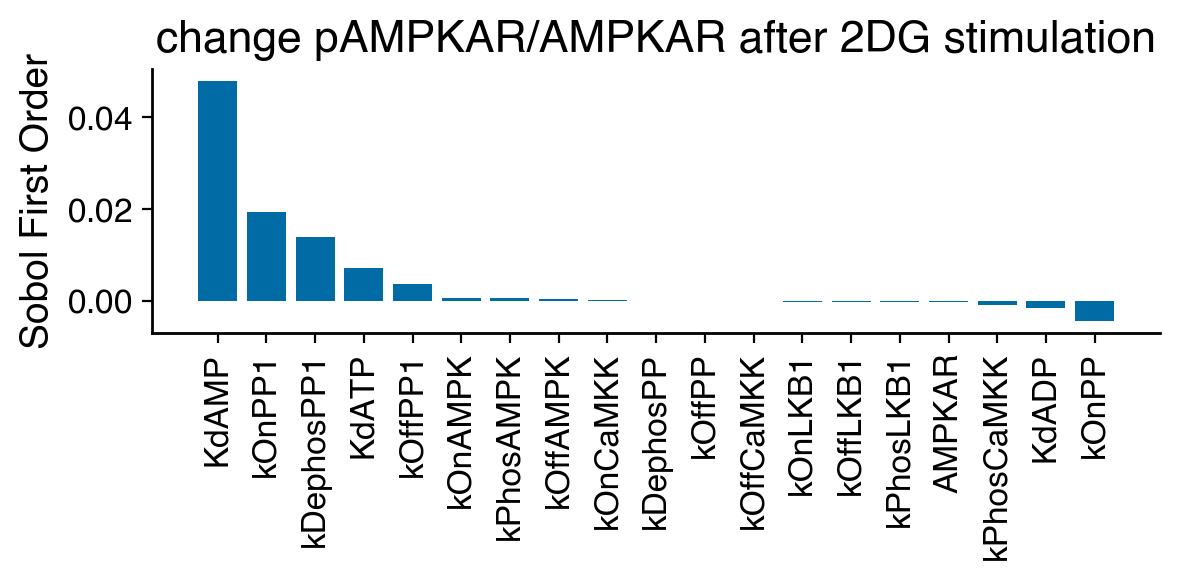

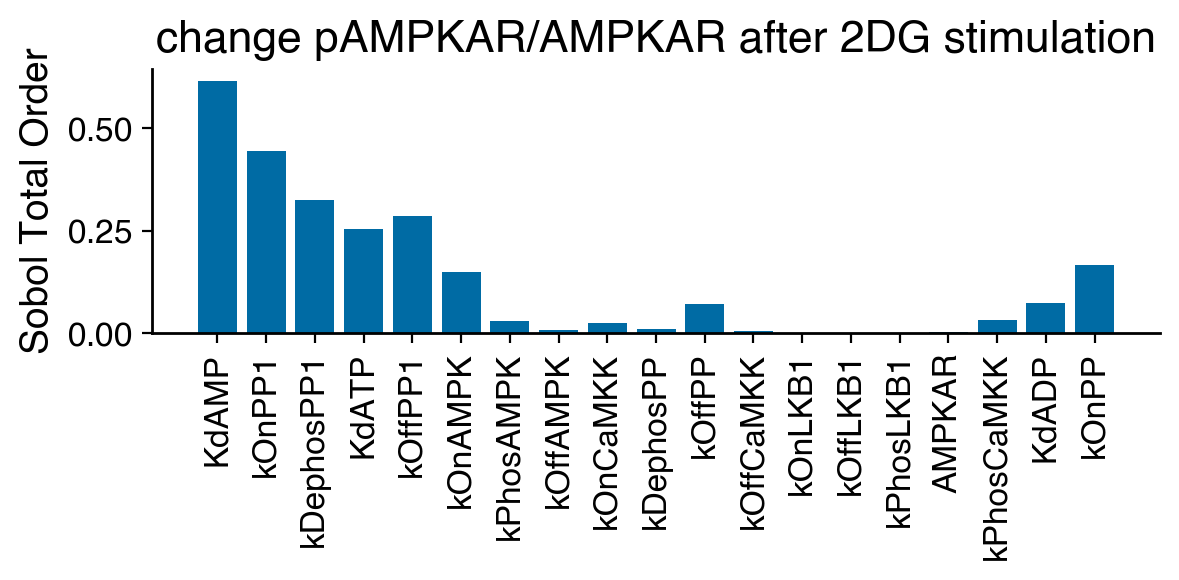

In [ ]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_S1_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,19), Si_sobol_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,19), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/GSA_MA_double_mech_ST_delta.pdf')
plt.show()

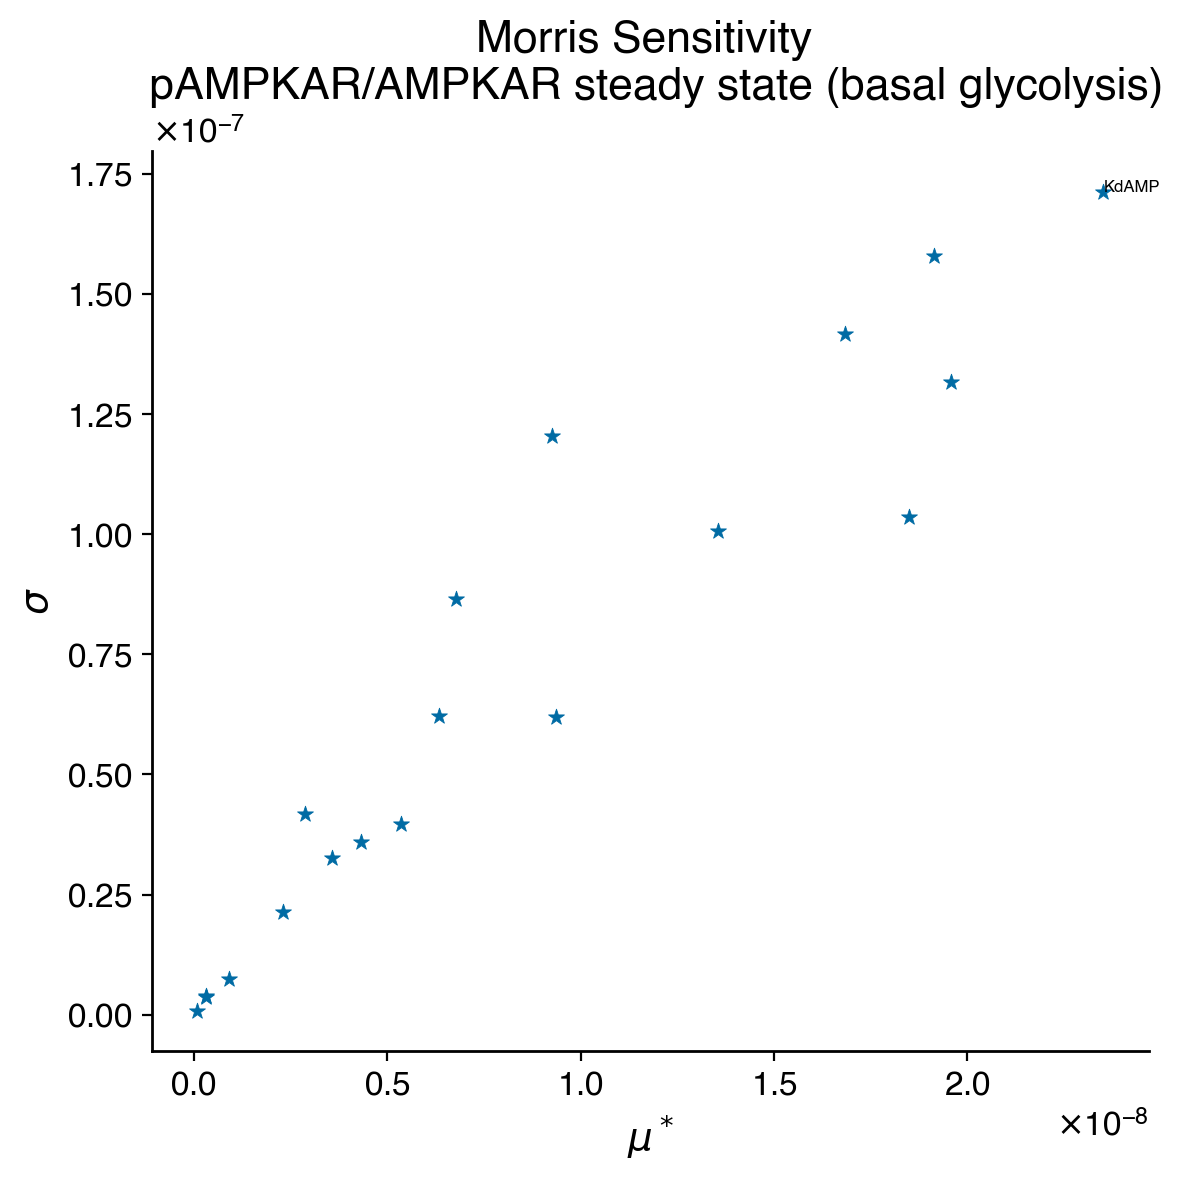

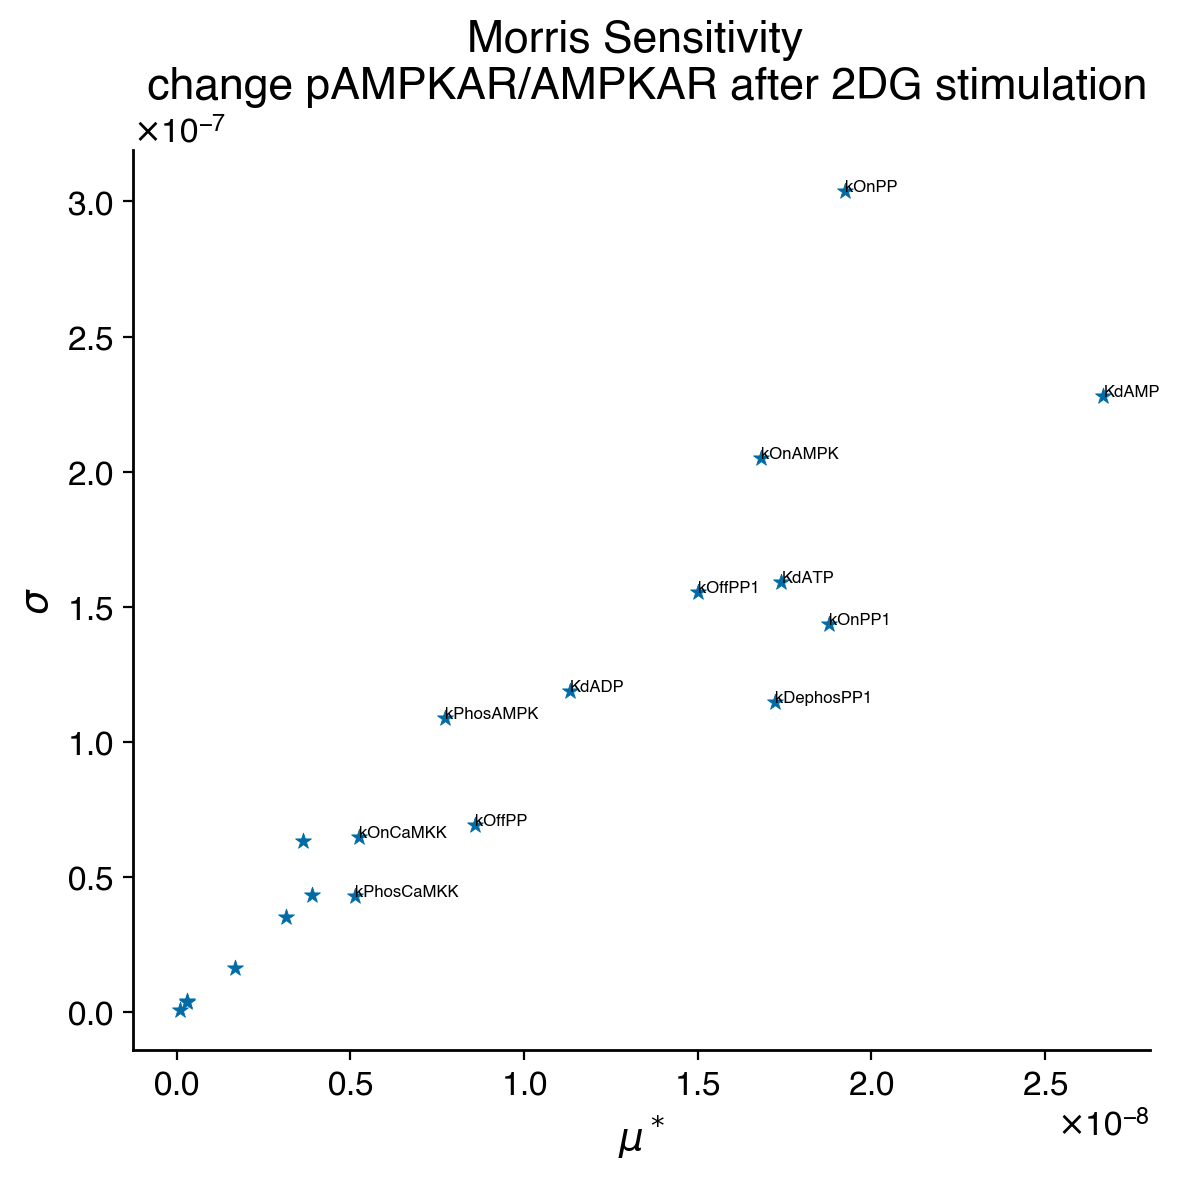

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_ss_sorted['mu_star'], Si_morris_ss_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_ss['names'], Si_morris_ss['mu_star'])):
    if name_mu_star[1] >= 2.0e-8:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_ss['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MA_double_mech/20230321_GSA_MA_double_mech_morris_ss.pdf')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_delta_sorted['mu_star'], Si_morris_delta_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 1e-10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_delta['names'], Si_morris_delta['mu_star'])):
    if name_mu_star[1] >= 5.0e-9:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_delta['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MA_double_mech/20230321_GSA_MA_double_mech_morris_delta.pdf')
